- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Explorando os dados


In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


In [2]:
def plot_flight_data_by_source(df, source_name, skip_noise=True):
    """
    df: DataFrame com o join completo
    source_name: String contida no nome das colunas (ex: 'battery' ou 'imu-data_raw')
    skip_noise: Se True, ignora colunas de covariância e metadados técnicos
    """
    # 1. Identificar colunas que pertencem a esta fonte
    # O padrão do join é: [NomeDoArquivo]_field.[Campo]
    cols = [c for c in df.columns if source_name in c and '_field.' in c]
    
    if skip_noise:
        noise_keywords = ['covariance', 'checksum', 'magic', 'seq', 'stamp', 'frame_id', 'sysid', 'compid', 'msgid']
        cols = [c for c in cols if not any(k in c.lower() for k in noise_keywords)]

    if not cols:
        print(f"Nenhuma coluna relevante encontrada para: {source_name}")
        return

    # 2. Configurar o layout dos gráficos
    n_cols = len(cols)
    fig, axes = plt.subplots(n_cols, 1, figsize=(15, 2.5 * n_cols), sharex=True)
    
    if n_cols == 1:
        axes = [axes]

    print(f"Plotando {n_cols} colunas de: {source_name}")
    
    # 3. Gerar os plots
    for i, col in enumerate(cols):
        clean_label = col.split('_field.')[-1] # Nome humano da variável
        axes[i].plot(df['%time'], df[col], label=clean_label, color='tab:blue')
        axes[i].set_ylabel(clean_label)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Time (%time)')
    plt.suptitle(f"Análise de Sensores: {source_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    
    # Salvar ou mostrar
    #plt.savefig(f"plot_{source_name.replace('-', '_')}.png")
    plt.show()

In [3]:
path = '../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure'
all_files = glob.glob(os.path.join(path, "*.csv"))

dfs = []

for filename in all_files:
    # Pega o nome do arquivo sem a extensão para usar como prefixo
    # Ex: 'engine_status' ou 'battery'
    topic_name = os.path.basename(filename).replace('.csv', '')
    
    temp_df = pd.read_csv(filename)
    
    # Identifica colunas numéricas
    cols = temp_df.select_dtypes(include=['number']).columns.tolist()
    if '%time' not in cols:
        temp_df['%time'] = pd.to_numeric(temp_df['%time'])
        cols.append('%time')
    
    temp_df = temp_df[cols].sort_values('%time')

    # RENOMEIA as colunas (exceto o tempo) para evitar colisão
    # field.data vira engine_status_field.data
    new_names = {c: f"{topic_name}_{c}" for c in temp_df.columns if c != '%time'}
    temp_df.rename(columns=new_names, inplace=True)
    
    dfs.append(temp_df)



In [4]:
import pandas as pd

# 1. Encontrar o timestamp inicial absoluto de todos os arquivos antes de qualquer processamento
min_time = min([df['%time'].min() for df in dfs])

# 2. Normalizar o tempo e ordenar cada DataFrame individualmente
processed_dfs = []
for df in dfs:
    # Criar uma cópia para não alterar a lista original acidentalmente
    temp_df = df.copy()
    temp_df['%time'] = (temp_df['%time'] - min_time) / 1e9
    temp_df = temp_df.sort_values('%time')
    processed_dfs.append(temp_df)

# 3. Ordenar a lista pelo tamanho para garantir que o dataframe base seja o mais denso
processed_dfs.sort(key=len, reverse=True)

# 4. Inicializar o dataframe principal
merged_df = processed_dfs[0]

# 5. Realizar o join iterativo
for next_df in processed_dfs[1:]:
    # Identificar colunas que ainda não estão no merged_df
    cols_to_use = next_df.columns.difference(merged_df.columns).tolist()
    if '%time' not in cols_to_use:
        cols_to_use.append('%time')
    
    # merge_asof com direção 'backward' para garantir que NaNs apareçam 
    # se o sensor ainda não tiver começado a registrar naquele timestamp
    merged_df = pd.merge_asof(
        merged_df, 
        next_df[cols_to_use], 
        on='%time', 
        direction='backward'
    )

# 6. Preencher todos os valores ausentes com 0
# Isso afetará tanto o início (sensores atrasados) quanto falhas de log no meio
merged_df.fillna(0, inplace=True)

# 7. (Opcional) Converter colunas de status/inteiras que ficaram como float após o NaN
# merged_df = merged_df.infer_objects() 

print(f"Merge concluído!")
print(f"Shape final: {merged_df.shape}")
print(f"Eixo temporal: de {merged_df['%time'].min():.2f}s a {merged_df['%time'].max():.2f}s")

Merge concluído!
Shape final: (26183, 531)
Eixo temporal: de 0.04s a 132.39s


- Diferente de um join comum, o merge_asof com nearest é o mais indicado para sensores de drones por dois motivos:

- Latência de Sensores: O sensor de GPS pode registrar às 10.001s e o acelerômetro às 10.002s. O nearest garante que eles se alinhem no "momento" mais próximo.

- Preenchimento de NaNs: Se você usar left ou right puro, terá muitos buracos nos dados onde as frequências não batem.

In [5]:
print(merged_df.columns.tolist())

['%time', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.seq', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.stamp', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.frame_id', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.framing_status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.magic', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.len', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.incompat_flags', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.compat_flags', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.seq', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.sysid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.compid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.msgid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.check

In [6]:
columns_field_data = [col for col in merged_df.columns if 'field.data' in col]

In [7]:
columns_field_data

['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data',
 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg_field.data',
 'carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data']

In [8]:
merged_df[columns_field_data]

,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg_field.data,carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data
0,0.000,0.00,0.0
1,0.000,0.00,0.0
2,0.000,0.00,0.0
3,0.000,0.00,0.0
4,0.000,0.00,0.0
...,...,...,...
26178,28.329,283.02,1.0
26179,28.329,283.02,1.0
26180,28.329,283.02,1.0
26181,28.329,283.02,1.0


# Verificando colunas

In [9]:
# Dicionário para organizar as colunas por arquivo
estrutura_colunas = {}

# Extrair as colunas associadas a cada fonte (arquivo CSV)
for col in merged_df.columns:
    if '_field.' in col:
        # Divide o nome: [Nome_do_Arquivo]_field.[Nome_da_Coluna]
        partes = col.split('_field.')
        fonte = partes[0].split('engine_failure-')[-1] # Pega só o nome do tópico/arquivo
        coluna_real = partes[1]
        
        if fonte not in estrutura_colunas:
            estrutura_colunas[fonte] = []
        estrutura_colunas[fonte].append(coluna_real)

# Imprimir de forma organizada para você copiar e me enviar
print("### ESTRUTURA DE COLUNAS POR ARQUIVO ###\n")
for arquivo in sorted(estrutura_colunas.keys()):
    print(f"Arquivo: {arquivo}")
    for c in estrutura_colunas[arquivo]:
        print(f"  - {c}")
    print("-" * 30)

### ESTRUTURA DE COLUNAS POR ARQUIVO ###

Arquivo: diagnostics
  - header.frame_id
  - header.seq
  - header.stamp
  - status0.level
  - status0.values0.value
  - status0.values1.value
  - status0.values2.value
  - status0.values3.value
  - status0.values4.value
  - status0.values5.value
  - status0.values6.value
  - status0.values7.value
  - status0.values8.value
  - status0.values9.value
  - status1.level
  - status1.values0.value
  - status1.values1.value
  - status1.values2.value
  - status1.values3.value
  - status2.level
  - status2.values0.value
  - status2.values1.value
  - status3.level
  - status3.values19.value
  - status3.values20.value
  - status3.values21.value
  - status3.values22.value
  - status3.values23.value
  - status3.values24.value
  - status3.values25.value
  - status4.level
  - status4.values0.value
  - status4.values1.value
  - status4.values2.value
------------------------------
Arquivo: failure_status-engines
  - data
------------------------------
Arquivo: 

# Filtrando apenas colunas e datasets que não são ruído

In [10]:
# 1. Definir termos que indicam colunas de ruído/metadados para descarte
descarte_keywords = [
    'covariance', 'header.', 'checksum', 'magic', 'seq', 'stamp', 
    'frame_id', 'sysid', 'compid', 'msgid', 'payload', 'incompat_flags', 
    'compat_flags', 'len', 'framing_status', 'time_ref', 'serial_number'
]

# 2. Definir se preferimos o IMU processado ou o RAW
# (Escolhemos o processado por ser mais estável, mas você pode inverter)
fonte_imu_para_descartar = 'imu-data_raw' 

# 3. Lista para armazenar as colunas que vamos manter
colunas_uteis = ['%time'] # O tempo é essencial

for col in merged_df.columns:
    # Ignorar a coluna de tempo (já adicionada)
    if col == '%time':
        continue
        
    # Critério de descarte por palavra-chave
    if any(key in col.lower() for key in descarte_keywords):
        continue
        
    # Critério de descarte de redundância (IMU RAW)
    if fonte_imu_para_descartar in col:
        continue
        
    # Se passou pelos filtros, é uma coluna de relevância (Alta, Média ou Baixa)
    colunas_uteis.append(col)

# 4. Criar o DataFrame final filtrado
df_final = merged_df[colunas_uteis].copy()

# 5. Organizar as colunas alfabeticamente (exceto %time) para facilitar a inspeção
cols_sorted = ['%time'] + sorted([c for c in df_final.columns if c != '%time'])
df_final = df_final[cols_sorted]

print(f"Colunas originais: {merged_df.shape[1]}")
print(f"Colunas após limpeza: {df_final.shape[1]}")
print("\nExemplos de colunas mantidas:")
print(df_final.columns[:10].tolist())

Colunas originais: 531
Colunas após limpeza: 210

Exemplos de colunas mantidas:
['%time', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.level', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values0.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values1.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values2.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values3.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values4.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values5.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values6.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values7.value']


In [11]:
# Descobrir todas as fontes (arquivos originais) presentes no join
fontes = set([c.split('_field.')[0] for c in df_final.columns if '_field.' in c])
print("Fontes detectadas no merge:")
for f in sorted(fontes):
    # Exibe apenas a parte final do nome para facilitar a leitura
    print(f" - {f.split('engine_failure-')[-1]}")



Fontes detectadas no merge:
 - diagnostics
 - failure_status-engines
 - mavctrl-path_dev
 - mavctrl-rpy
 - mavros-battery
 - mavros-global_position-compass_hdg
 - mavros-global_position-global
 - mavros-global_position-local
 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-airspeed
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-vfr_hud
 - mavros-wind_estimation


In [12]:
# Lista dos nomes curtos dos arquivos que você quer filtrar
arquivos_alvo = [
    'diagnostics', 
    'failure_status-engines', 
    'mavctrl-path_dev', 
    'mavlink-from'
]

# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df_final.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df_final[colunas_selecionadas].columns.tolist())



Foram encontradas 35 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.level', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values0.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values1.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values2.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values3.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values4.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values5.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values6.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values7.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values8.value', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status0.values9.value', 'carbonZ_

Plotando 31 colunas de: diagnostics


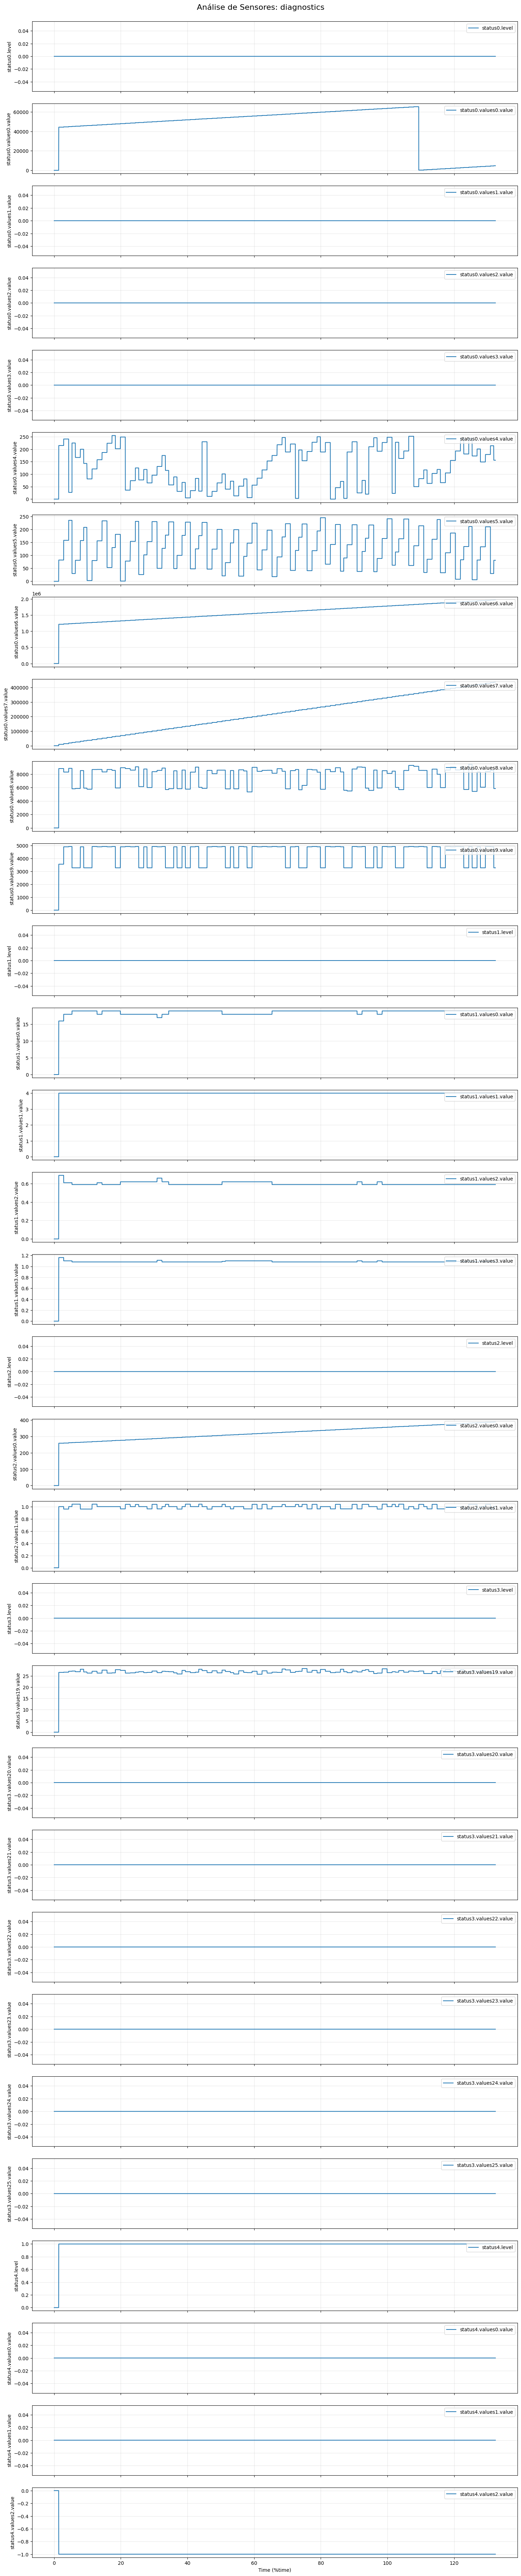

Plotando 1 colunas de: failure_status-engines


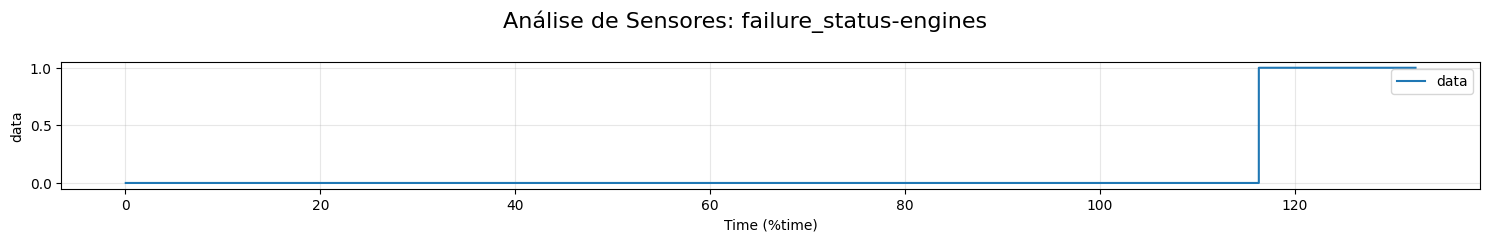

Plotando 3 colunas de: mavctrl-path_dev


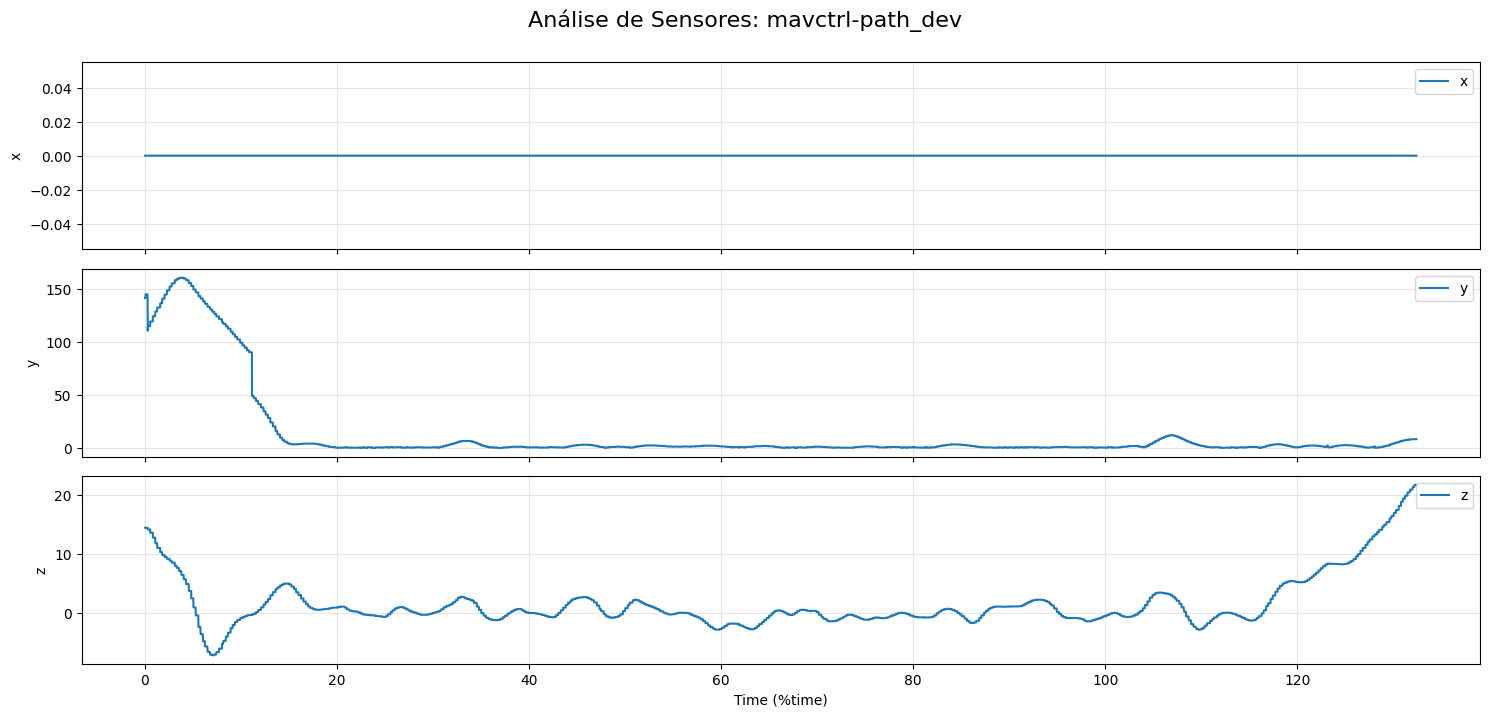

Nenhuma coluna relevante encontrada para: mavlink-from


In [13]:
for p in arquivos_alvo:
    plot_flight_data_by_source(df_final, p)

In [14]:
# 1. Identificar as colunas que queremos remover
colunas_para_remover = [col for col in df_final.columns 
                        if 'diagnostics' in col or 'mavlink-from' in col]

# 2. Remover do DataFrame
df1 = df_final.drop(columns=colunas_para_remover)

print(f"Colunas removidas: {len(colunas_para_remover)}")
print(f"Colunas restantes no dataset: {df1.shape[1]}")

# 3. Verificar o que sobrou (opcional)
# print(df_final.columns.tolist())

Colunas removidas: 31
Colunas restantes no dataset: 179


In [15]:
# Lista dos nomes curtos dos arquivos que você quer filtrar
arquivos_alvo = [
    'diagnostics', 
    'failure_status-engines', 
    'mavctrl-path_dev', 
    'mavlink-from'
]

# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df1.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df1[colunas_selecionadas].columns.tolist())

Foram encontradas 4 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavctrl-path_dev_field.x', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavctrl-path_dev_field.y', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavctrl-path_dev_field.z']


# Explicação de algumas colunas

1. failure_status-engines_field.data

    O que é: O Gabarito (Ground Truth).

    Explicação: É um sinal booleano (0 ou 1). No instante em que este valor passa de 0 para 1, a falha de motor foi injetada no sistema.

    Uso na IA: É a variável que você quer prever. O objetivo do seu modelo é identificar mudanças nos outros sinais (como os desvios abaixo) que ocorram simultaneamente ou logo após esse 1 aparecer.

2. mavctrl-path_dev_field.x (Desvio Longitudinal)

    O que é: Erro de posição no eixo de movimento (frente/trás).

    Explicação: Representa a distância entre onde o drone deveria estar na linha do tempo da missão e onde ele realmente está ao longo da trajetória.

    Comportamento na Falha: Quando o motor para, o drone perde velocidade. Ele começa a ficar "atrasado" em relação ao ponto ideal da missão. Você verá o valor de x aumentar (ou ficar mais negativo, dependendo da convenção), indicando que o drone não consegue mais acompanhar o ritmo planejado.

3. mavctrl-path_dev_field.y (Desvio Lateral)

    O que é: Erro de posição lateral (esquerda/direita).

    Explicação: Mede o quanto o drone saiu "para o lado" da linha reta da missão (o Cross-track error).

    Comportamento na Falha: Em aviões (asa fixa), a perda de motor pode gerar um torque assimétrico ou, mais comum, a perda de autoridade de controle das superfícies (leme/aileron) devido à baixa velocidade. Se houver vento lateral, o drone será "empurrado" para fora da rota, e o valor de y subirá drasticamente porque o drone não tem mais propulsão para corrigir o curso.

4. mavctrl-path_dev_field.z (Desvio Vertical / Altitude)

    O que é: Erro de altitude.

    Explicação: A diferença entre a altitude desejada e a altitude real.

    Comportamento na Falha: Este é o indicador mais dramático em aeronaves de asa fixa. Sem motor, não há sustentação suficiente para manter o voo nivelado. O drone começa a perder altura.

    O Gráfico: Se a missão pede 50m de altura e o drone cai para 40m, o path_dev.z mostrará um erro de 10m. É a confirmação física de que o drone está em um mergulho não planejado.

# Fontes a verificar

 - mavros-battery
 - mavros-global_position-compass_hdg
 - mavros-global_position-global
 - mavros-global_position-local
 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-airspeed
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-vfr_hud
 - mavros-wind_estimation

In [16]:
# Lista dos nomes curtos dos arquivos que você quer filtrar
arquivos_alvo = [
    'mavros-battery', 
    'mavros-global_position-compass_hdg', 
    'mavros-global_position-global', 
    'mavros-global_position-local'
]

# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df1.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df1[colunas_selecionadas].columns.tolist())



Foram encontradas 30 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.capacity', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.charge', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.current', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.design_capacity', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.location', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.percentage', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.power_supply_health', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.power_supply_status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.power_supply_technology', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.present', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.voltage', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-c

# Explicação das colunas

1. mavros-battery (Estado Elétrico)

Como você já observou que a bateria é estável no ALFA Dataset, a maioria dessas colunas será constante, mas duas são vitais para confirmar que não houve um "apagão":

- current: Corrente elétrica. Mesmo estável, ela deve cair levemente se o motor para de consumir energia.

- voltage: Tensão. Se o motor trava e tenta girar (curto), a voltagem cai (sag). Se o circuito abre, a voltagem sobe levemente.

- percentage: Útil apenas para saber o estado geral de carga.

- Descarte: design_capacity, location, serial_number, technology. São metadados estáticos (não mudam nunca).

2. mavros-global_position-global & compass_hdg

Aqui temos os dados do GPS e da bússola magnética.

- compass_hdg_field.data: O Heading (direção) da bússola. Se o motor falha e o avião começa a girar (guinada), este valor mudará de forma não planejada.

- altitude: Altitude absoluta (MSL). Crucial para ver a queda do avião.

- latitude / longitude: Úteis para plotar o mapa do voo, mas péssimas para modelos de IA (números muito grandes e mudanças pequenas dificultam o aprendizado).

- status.status: Indica se o GPS está com sinal (fix). Se o motor causar interferência eletromagnética ao falhar, o status pode oscilar.

3. mavros-global_position-local (Cinemática do Voo)

Este é o arquivo mais rico em física depois do IMU. Ele transforma os dados globais em um plano local (X, Y, Z), o que é muito melhor para a IA processar.

- pose.pose.position.z: É a altitude local. Muito mais fácil de usar que a altitude global para detectar quedas.

- twist.twist.linear.x, y, z: Velocidades lineares.

    - O linear.x é a velocidade de avanço. Se o motor para, ela cai.

    - O linear.z é a velocidade vertical. Se o motor para, ela fica negativa (descida).

- twist.twist.angular.x, y, z: Velocidades angulares. Medem o "balanço" do drone. Se o avião começar a "capotar" ou girar após a falha, esses valores explodem.

- pose.pose.orientation.w, x, y, z: A atitude do drone (Quatérnios). Representam a inclinação.

Plotando 11 colunas de: mavros-battery


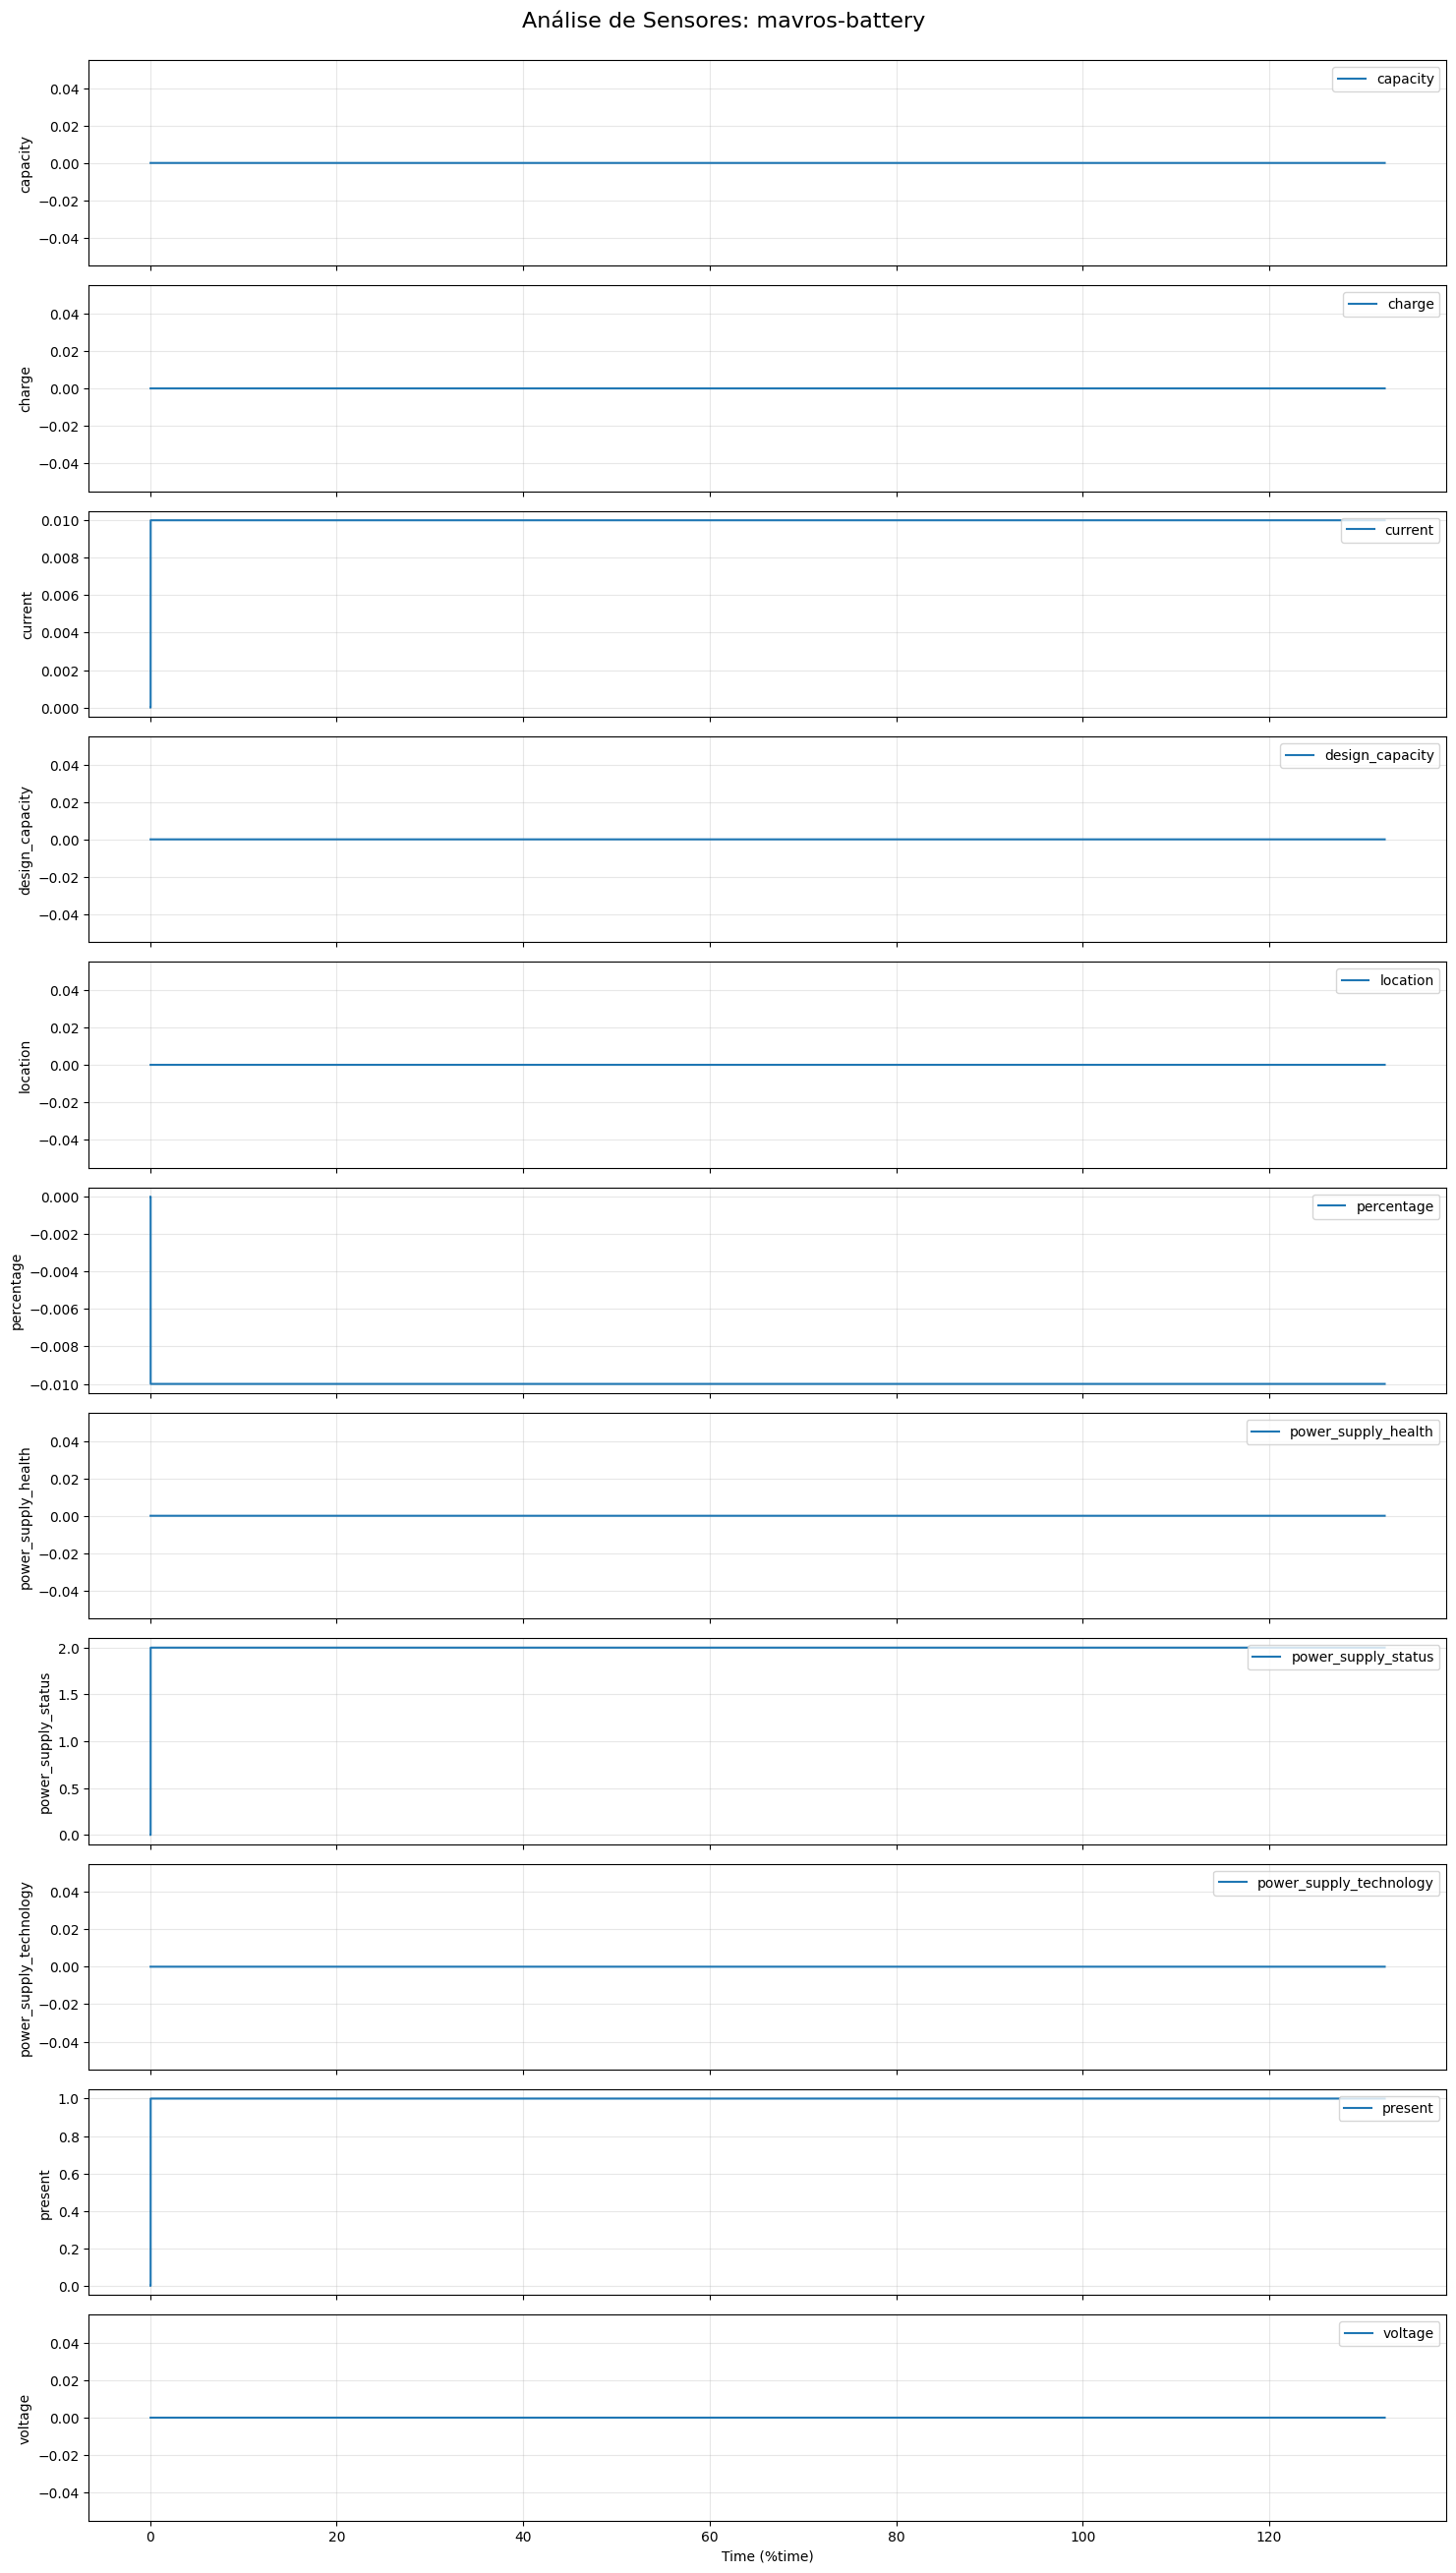

Plotando 1 colunas de: mavros-global_position-compass_hdg


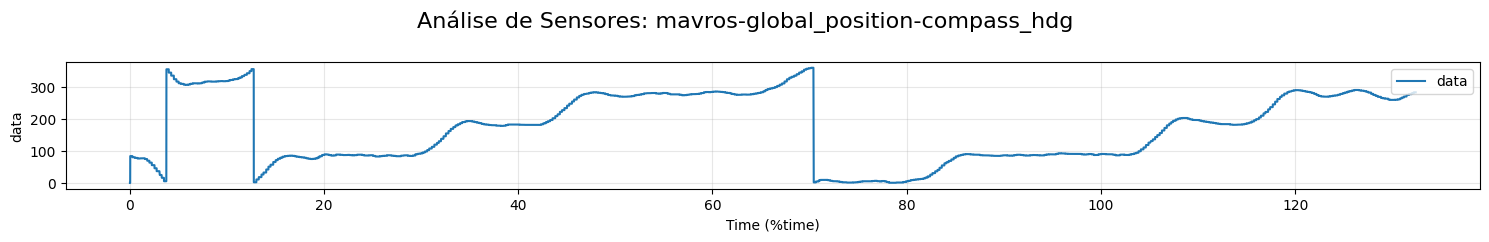

Plotando 5 colunas de: mavros-global_position-global


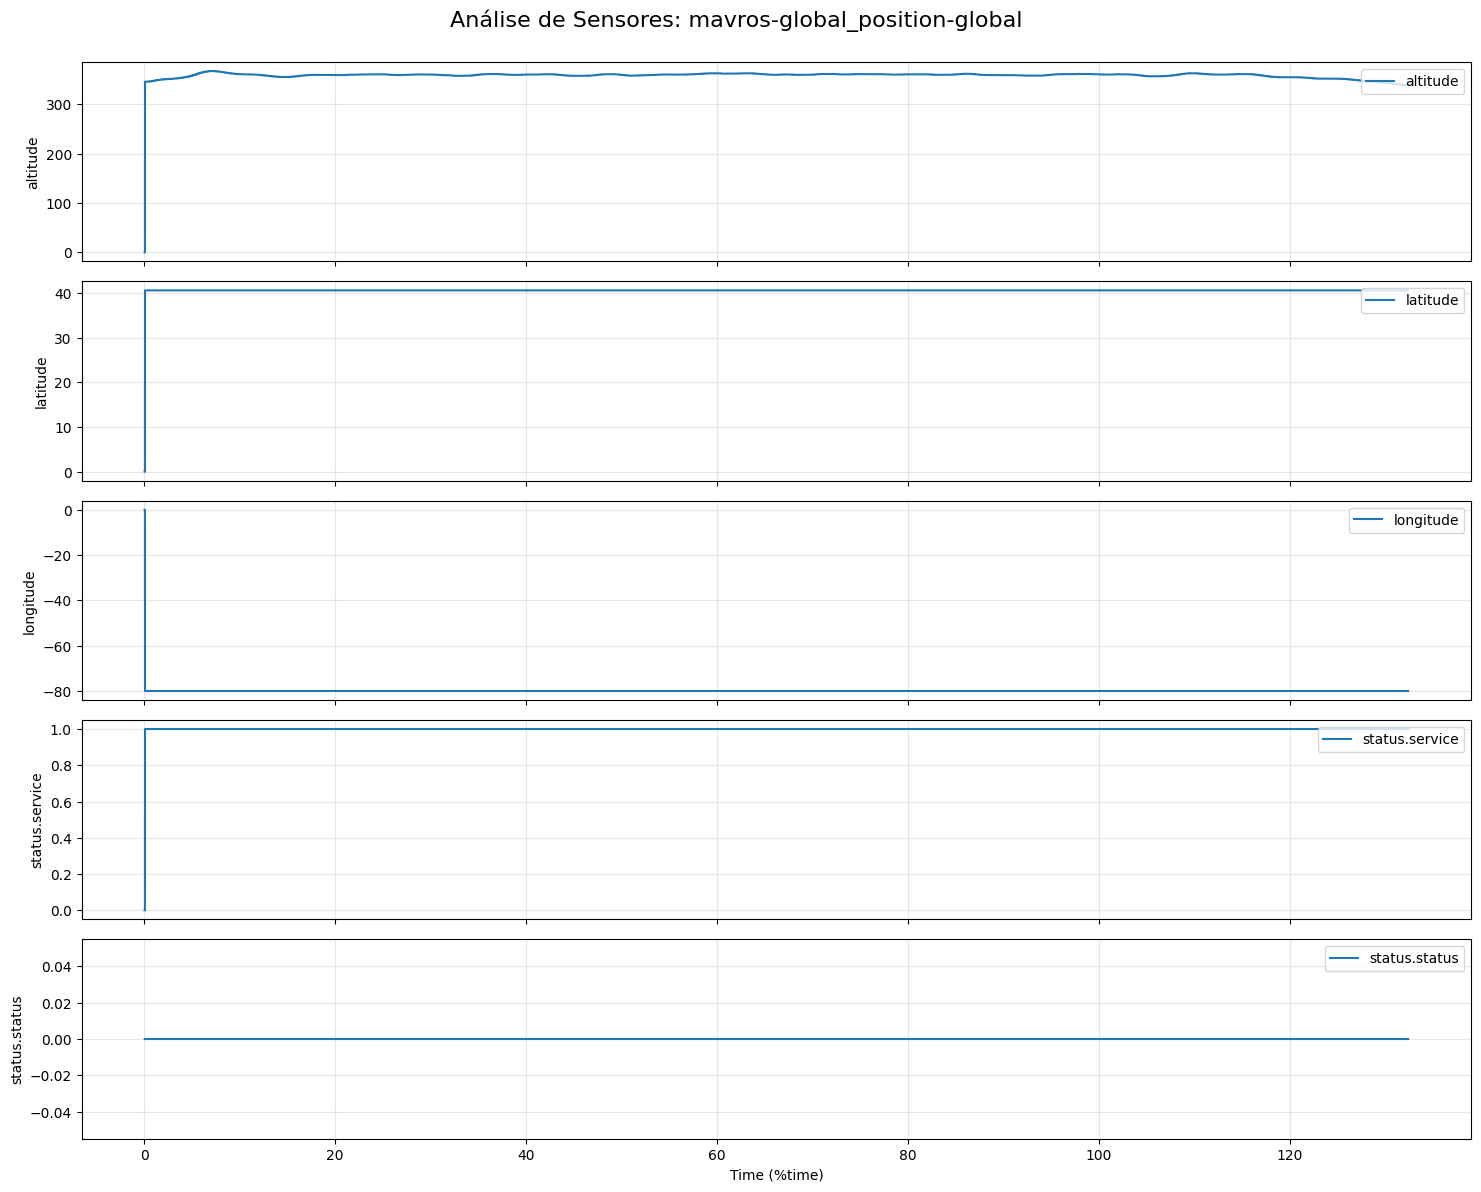

Plotando 13 colunas de: mavros-global_position-local


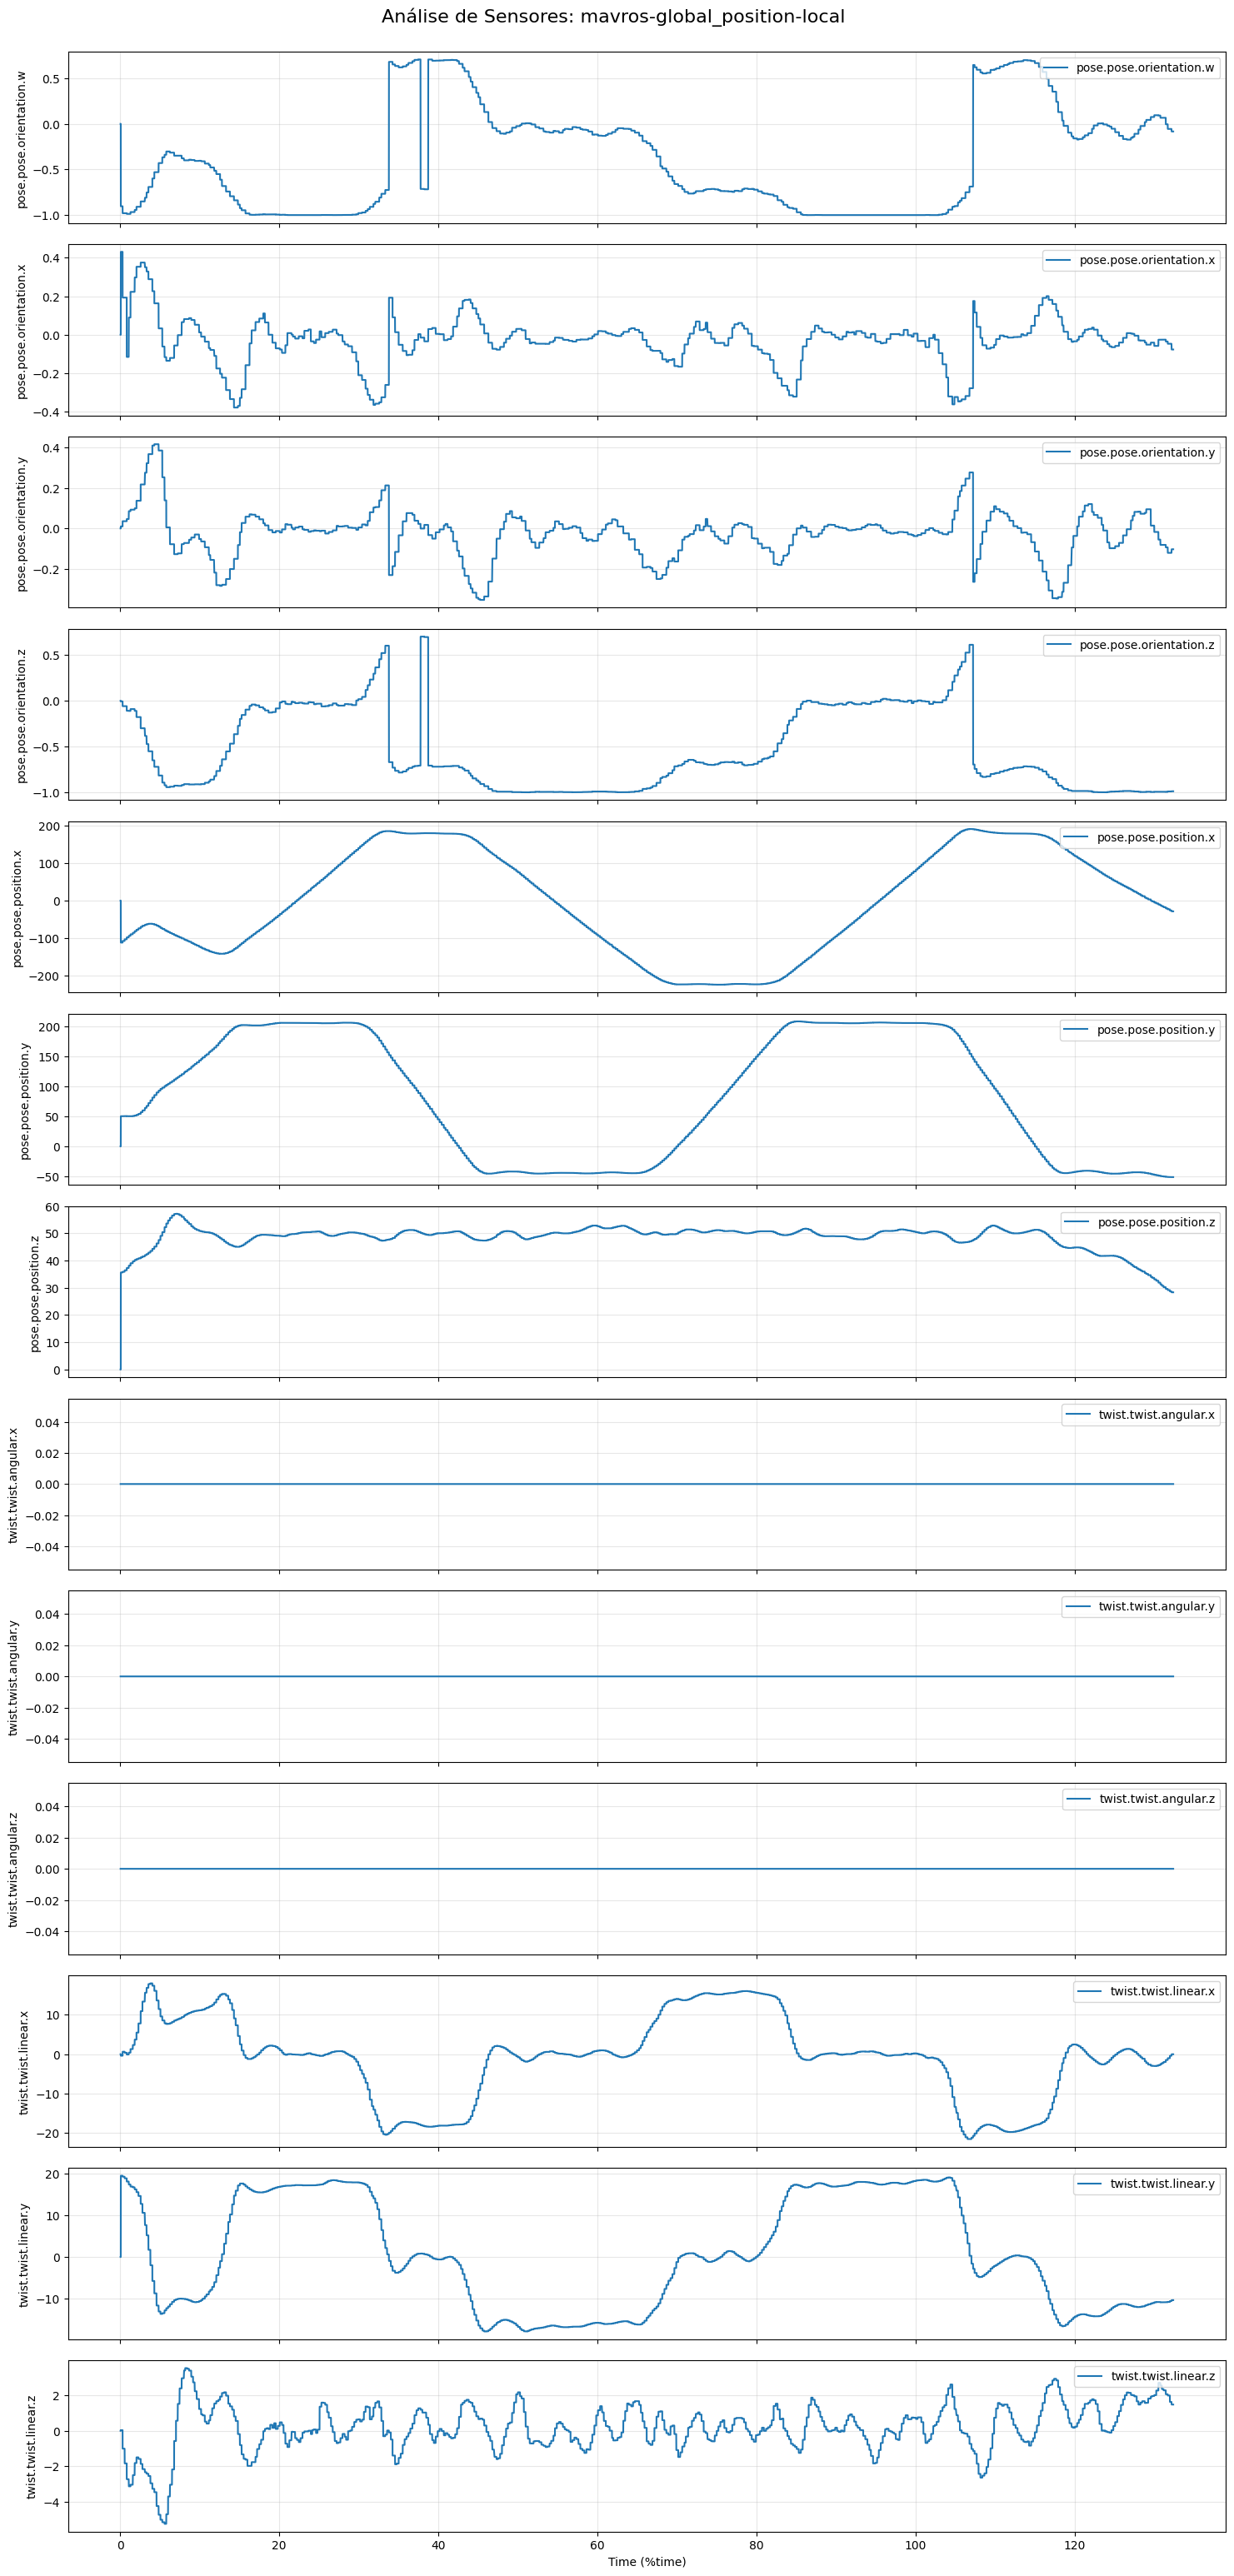

In [17]:
for p in arquivos_alvo:
    plot_flight_data_by_source(df1, p)

In [18]:
# 1. Lista de termos que identificam colunas irrelevantes (metadados e status estáticos)
termos_inuteis = [
    'design_capacity', 'location', 'present', 'serial_number', 
    'technology', 'power_supply_health', 'power_supply_technology',
    'status.service', 'capacity', 'charge'
]

# 2. Identificar todas as colunas no merged_df que contenham algum desses termos
colunas_para_deletar = [col for col in df1.columns 
                        if any(termo in col.lower() for termo in termos_inuteis)]

# 3. Remover as colunas do DataFrame
df2 = df1.drop(columns=colunas_para_deletar)

# 4. Remover também Latitude e Longitude se você for usar apenas a posição LOCAL
# GPS global costuma ter números muito grandes que atrapalham redes neurais
colunas_gps_global = [col for col in df2.columns if 'latitude' in col or 'longitude' in col]
df2 = df2.drop(columns=colunas_gps_global)

print(f"Total de colunas deletadas: {len(colunas_para_deletar) + len(colunas_gps_global)}")
print(f"Colunas restantes para análise: {df2.shape[1]}")


Total de colunas deletadas: 15
Colunas restantes para análise: 164


In [19]:
# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df2.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df1[colunas_selecionadas].columns.tolist())

Foram encontradas 20 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.current', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.percentage', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.power_supply_status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery_field.voltage', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg_field.data', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global_field.altitude', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global_field.status.status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-local_field.pose.pose.orientation.w', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-local_field.pose.pose.orientation.x', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-local_field.pose.pose.orientation.y', 'carbonZ_2018-07-18-15-53-31_1_engine_fa

# Fontes a verificar

 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-airspeed
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-vfr_hud
 - mavros-wind_estimation

In [20]:
# Lista dos nomes curtos dos arquivos que você quer filtrar
arquivos_alvo = [
    'mavros-global_position-raw-fix', 
    'mavros-global_position-raw-gps_vel', 
    'mavros-global_position-rel_alt', 
    'mavros-imu-atm_pressure'
]

# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df2.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df1[colunas_selecionadas].columns.tolist())



Foram encontradas 11 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix_field.altitude', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix_field.status.status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.angular.x', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.angular.y', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.angular.z', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.linear.x', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.linear.y', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.linear.z', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-at

# Explicação das colunas

1. Dados de Altitude e Pressão (Verticalidade)

- raw-fix_field.altitude: É a altitude bruta medida pelo GPS (em relação ao nível do mar).

    - Na falha: Esse número deve diminuir conforme o avião perde sustentação.

- rel_alt_field.data: Altitude Relativa. É a altura do drone em relação ao ponto de decolagem.

    - Relevância: Alta. Para IAs, essa coluna é melhor que a altitude absoluta porque começa em 0 ou perto disso, facilitando a detecção de quedas.

- atm_pressure_field.fluid_pressure: Pressão atmosférica medida pelo barômetro.

    - Física: Conforme o avião cai (perde altitude), a pressão atmosférica aumenta.

    - Importância: É um sensor independente do GPS. Se o GPS falhar, a pressão te diz se o avião está caindo.

2. Velocidade e Movimento GPS (Cinemática Bruta)

Essas colunas vêm do arquivo raw-gps_vel e mostram o deslocamento medido diretamente pelos satélites:

- twist.linear.x, y, z: Velocidades lineares no plano terra.

    - linear.x: Velocidade para o Norte/Frente.

    - linear.z: Velocidade vertical (Subida/Descida). Se o motor para, este valor fica negativo (indicando descida).

- twist.angular.x, y, z: Velocidades angulares (Taxa de rotação).

    - Nota: No GPS, esses valores costumam ser menos precisos que os da IMU (Giroscópio), mas ajudam a entender se o avião entrou em um "parafuso" ou está girando sem controle após a perda de potência.

3. Status e Ruído

- raw-fix_field.status.status: Indica a qualidade do sinal GPS (ex: 0 = No Fix, 2 = Fix, 3 = DGPS).

    - Uso: Serve apenas para validar se os dados de altitude acima são confiáveis.

- atm_pressure_field.variance: O "ruído" ou erro estimado do sensor de pressão.

    - Relevância: Baixa. Pode ser descartada, pois não descreve o voo, apenas a precisão do sensor.

Plotando 2 colunas de: mavros-global_position-raw-fix


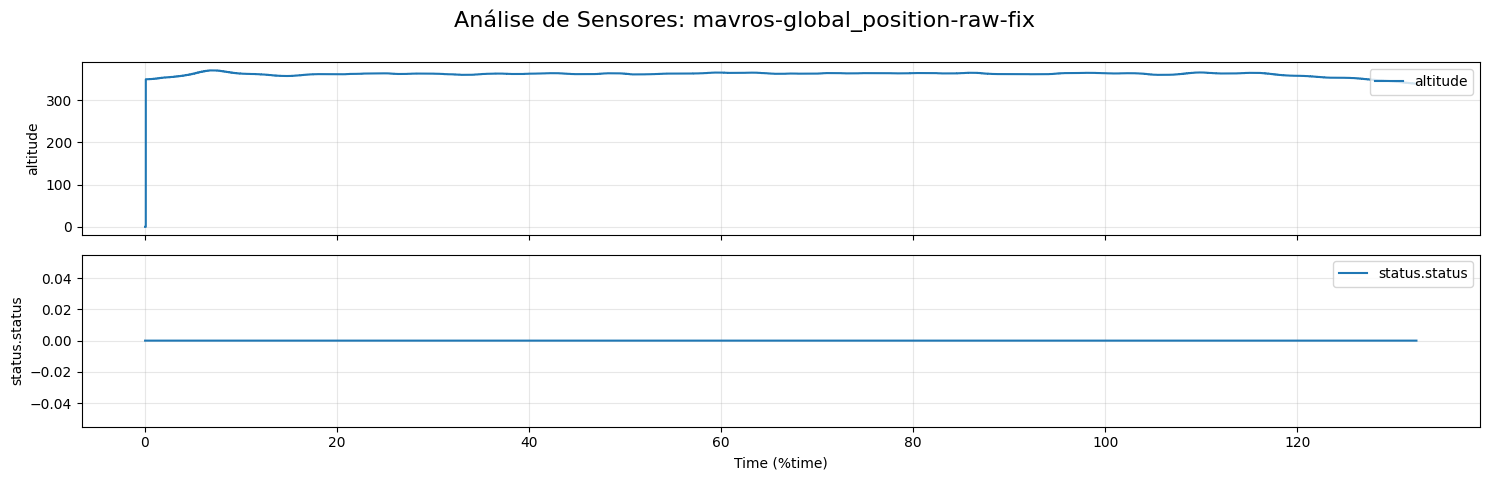

Plotando 6 colunas de: mavros-global_position-raw-gps_vel


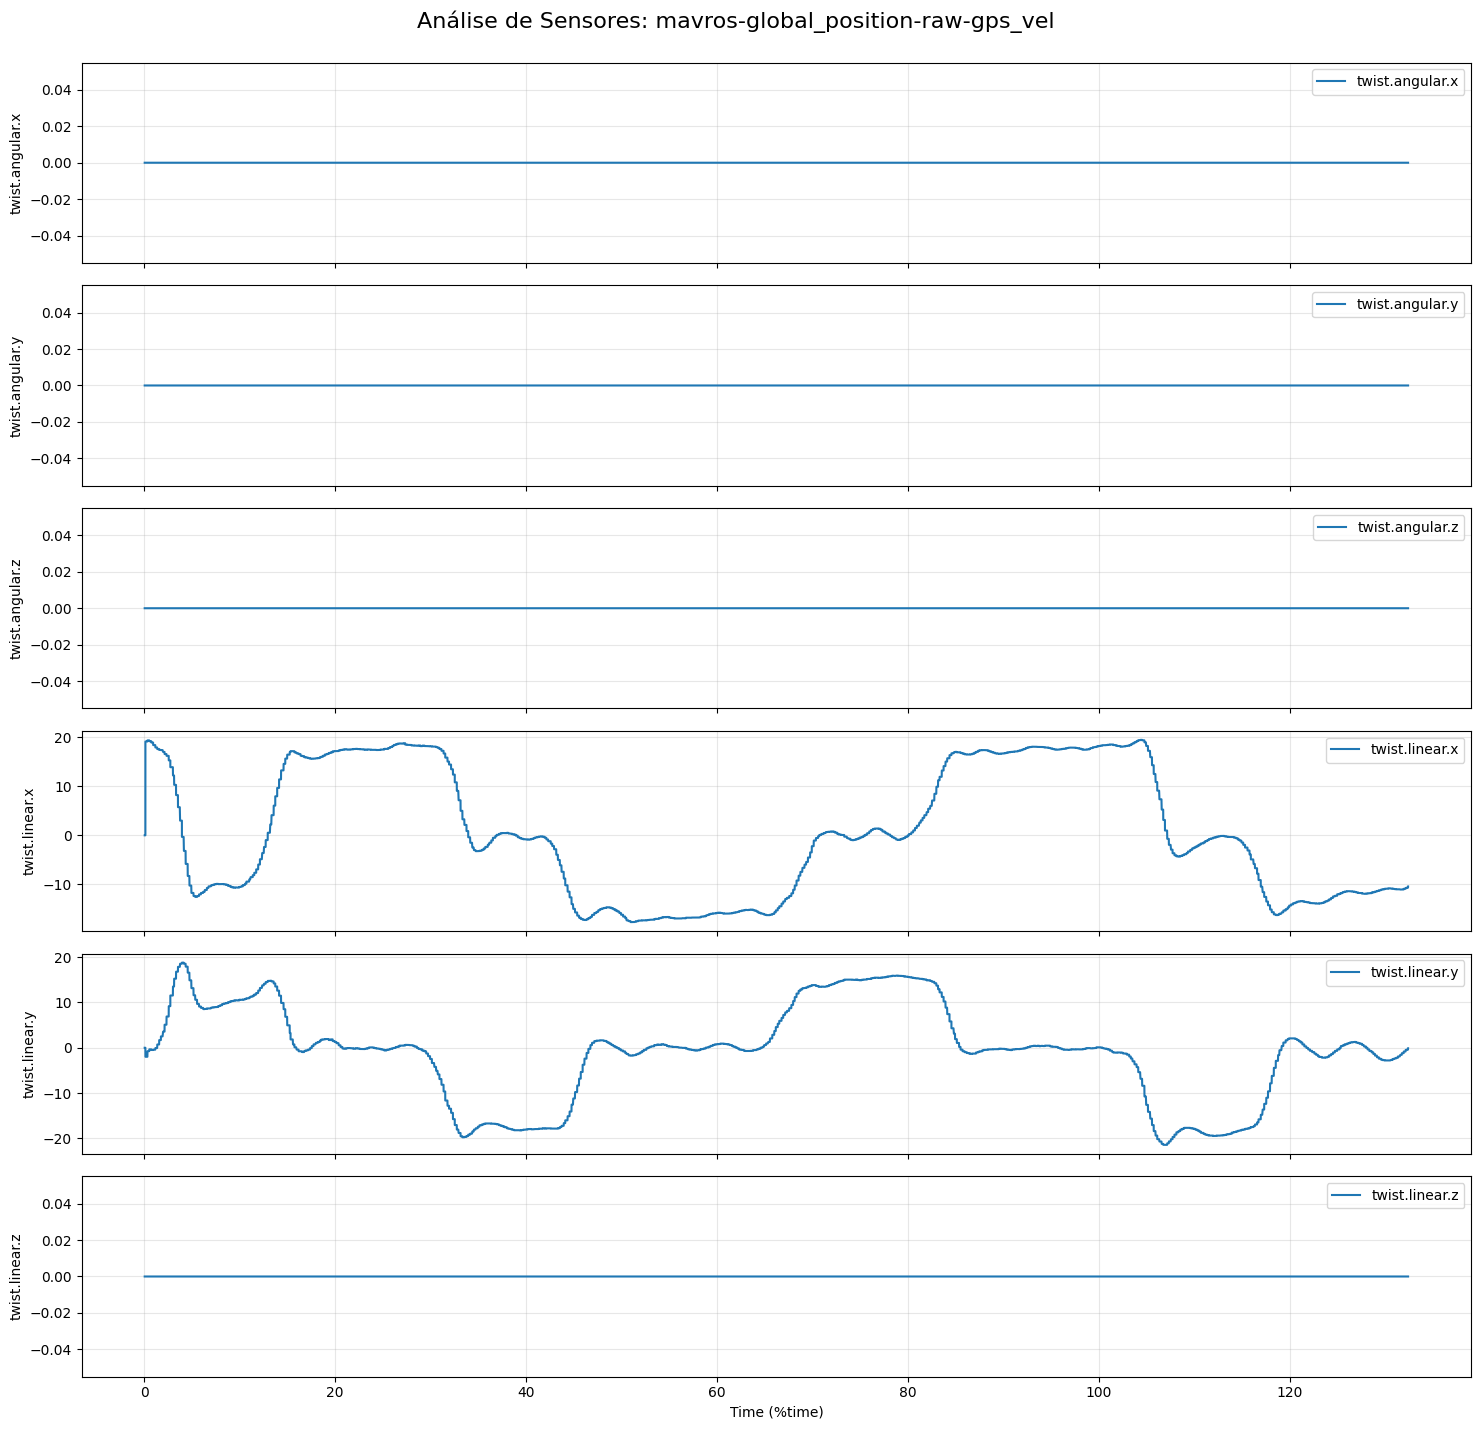

Plotando 1 colunas de: mavros-global_position-rel_alt


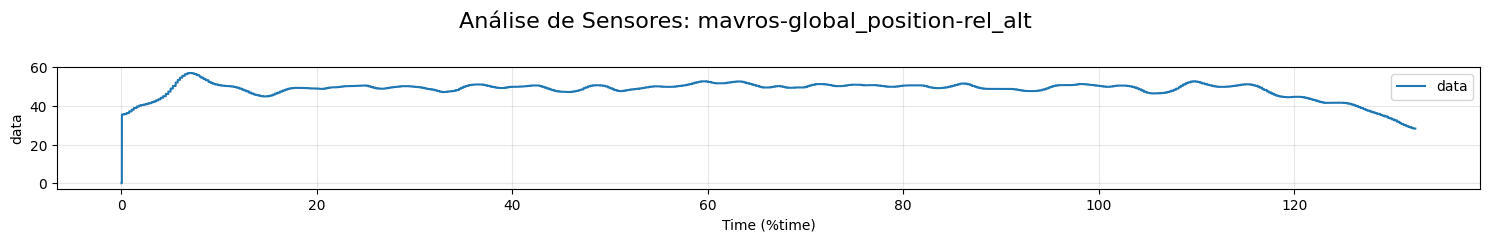

Plotando 2 colunas de: mavros-imu-atm_pressure


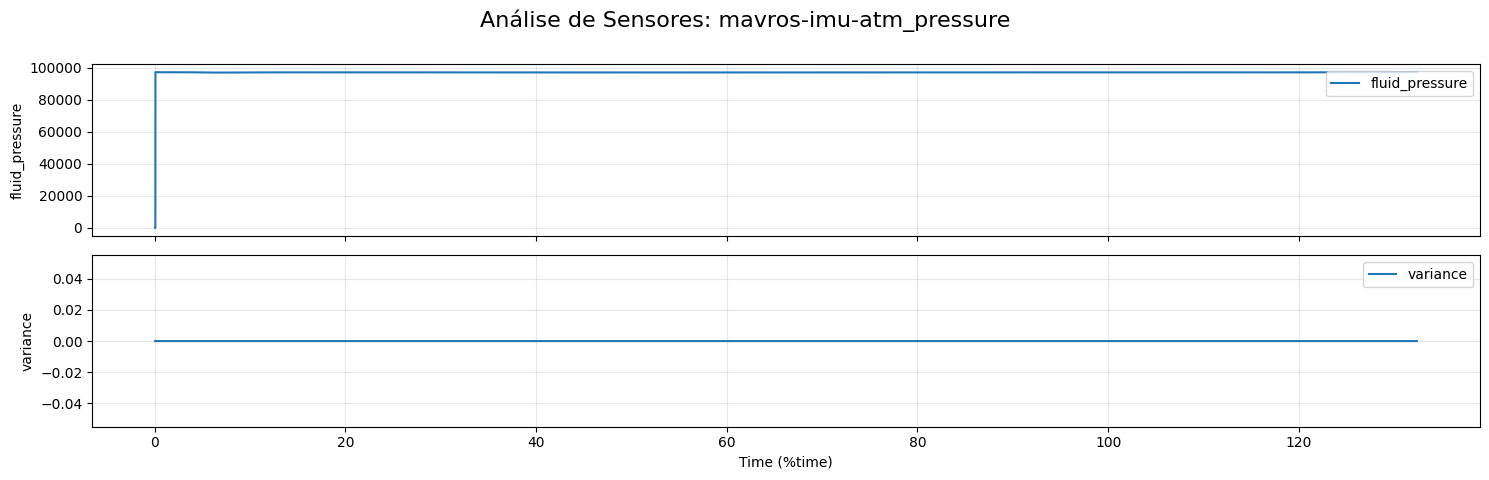

In [21]:
for p in arquivos_alvo:
    plot_flight_data_by_source(df2, p)

In [24]:
# 1. Lista de termos que identificam colunas irrelevantes (metadados e status estáticos)
termos_inuteis = [
    'status.status', 'variance', 'twist.linear.z', 'twist.angular.x', 
    'twist.angular.y', 'twist.angular.z'
]

# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df2.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)


# 2. Identificar todas as colunas no merged_df que contenham algum desses termos
colunas_para_deletar = [col for col in df2[colunas_selecionadas].columns 
                        if any(termo in col.lower() for termo in termos_inuteis)]

# 3. Remover as colunas do DataFrame
df3 = df2.drop(columns=colunas_para_deletar)


print(f"Total de colunas deletadas: {len(colunas_para_deletar)}")
print(f"Colunas restantes para análise: {df3.shape[1]}")


Total de colunas deletadas: 6
Colunas restantes para análise: 158


In [25]:
# Criar uma lista com todas as colunas que pertencem a esses arquivos
colunas_selecionadas = []
for col in df3.columns:
    # Verifica se o nome de algum dos arquivos alvo está presente no nome da coluna
    if any(arquivo in col for arquivo in arquivos_alvo):
        colunas_selecionadas.append(col)

# Exibir as colunas encontradas
print(f"Foram encontradas {len(colunas_selecionadas)} colunas.")
print(df1[colunas_selecionadas].columns.tolist())

Foram encontradas 5 colunas.
['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix_field.altitude', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.linear.x', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel_field.twist.linear.y', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-atm_pressure_field.fluid_pressure']


Plotando 1 colunas de: mavros-global_position-raw-fix


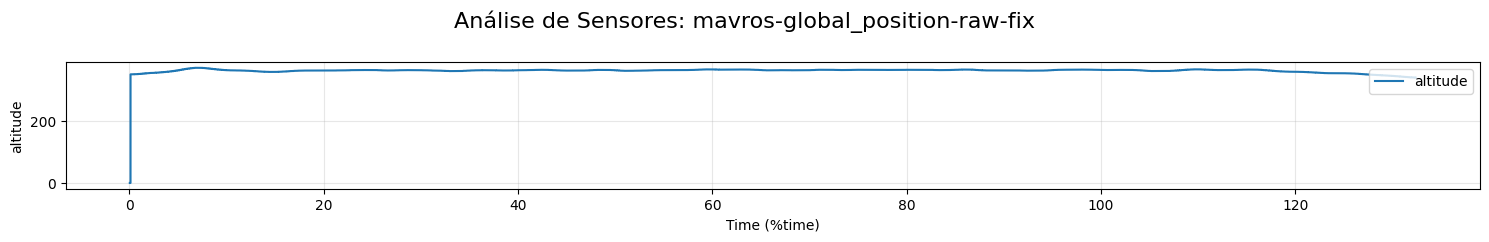

Plotando 2 colunas de: mavros-global_position-raw-gps_vel


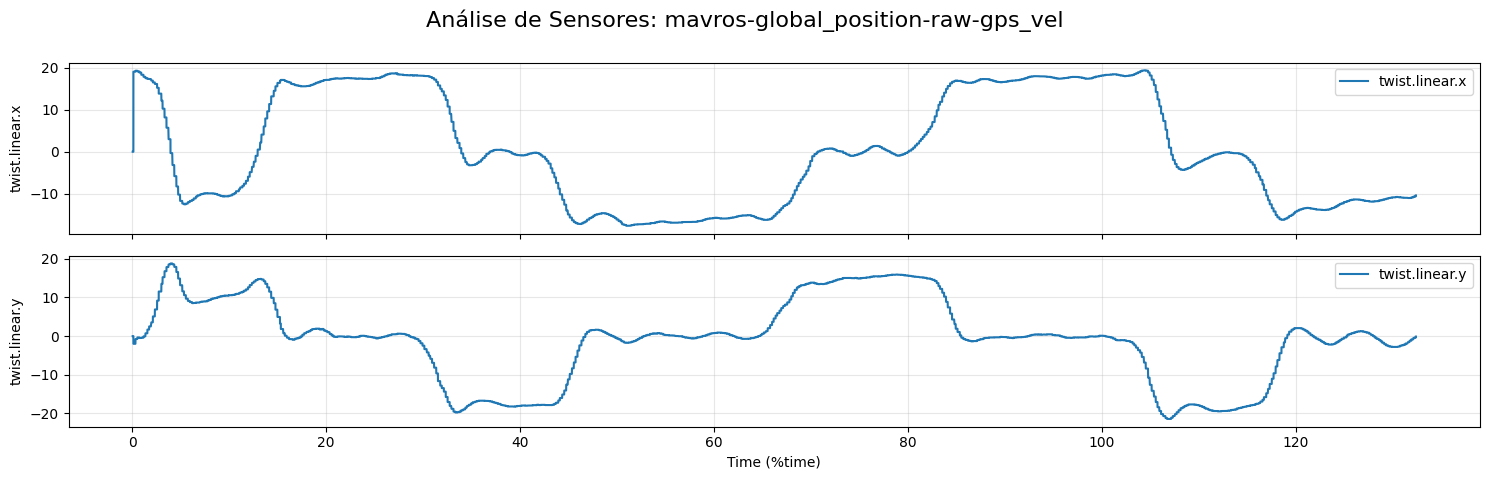

Plotando 1 colunas de: mavros-global_position-rel_alt


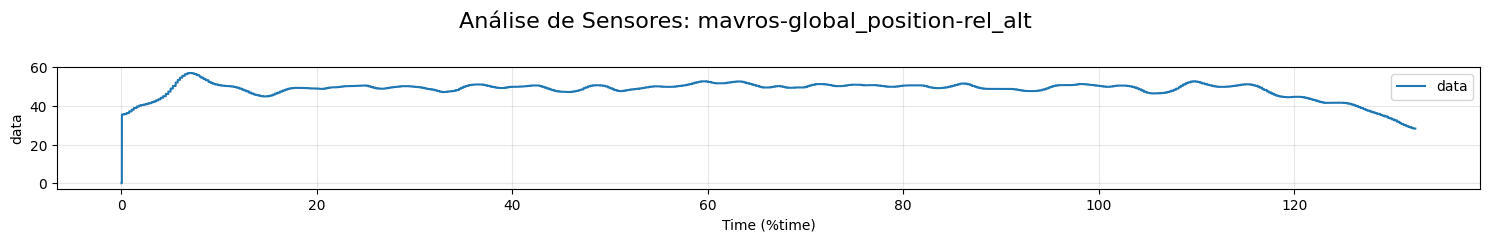

Plotando 1 colunas de: mavros-imu-atm_pressure


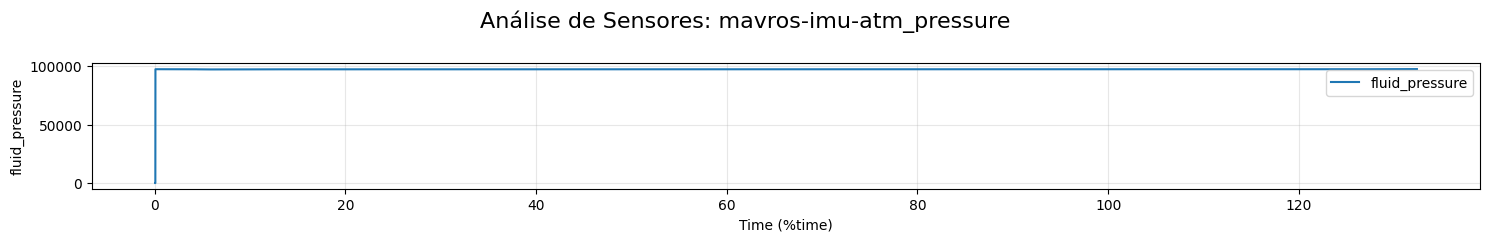

In [26]:
for p in arquivos_alvo:
    plot_flight_data_by_source(df3, p)